# Adult Income Classification

Predicting whether an individual's income exceeds $50K/year using the Adult Census Income dataset.


## 1. Imports


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                                f1_score, confusion_matrix, classification_report,
                                roc_curve, roc_auc_score, ConfusionMatrixDisplay)

## 2. Load & Explore the Data


In [3]:
df = pd.read_csv("adult.csv")
df.head(15)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(24)

## 3. Data Cleaning


In [9]:
df.drop_duplicates(inplace=True)
for i in df.columns:
    df[i] = df[i].replace('?', np.nan)
df.dropna(inplace=True)
df.shape

(30139, 15)

## 4. Categorical Encoding


In [10]:
le = LabelEncoder()
cat = df.select_dtypes(include=['object']).columns
for i in cat:
    df[i] = le.fit_transform(df[i])
df.head(15)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
3,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
5,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
6,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0
7,74,5,88638,10,16,4,9,2,4,0,0,3683,20,38,1
8,68,0,422013,11,9,0,9,1,4,0,0,3683,40,38,0
10,45,2,172274,10,16,0,9,4,2,0,0,3004,35,38,1
11,38,4,164526,14,15,4,9,1,4,1,0,2824,45,38,1
12,52,2,129177,9,13,6,7,1,4,0,0,2824,20,38,1


## 5. Correlation Analysis


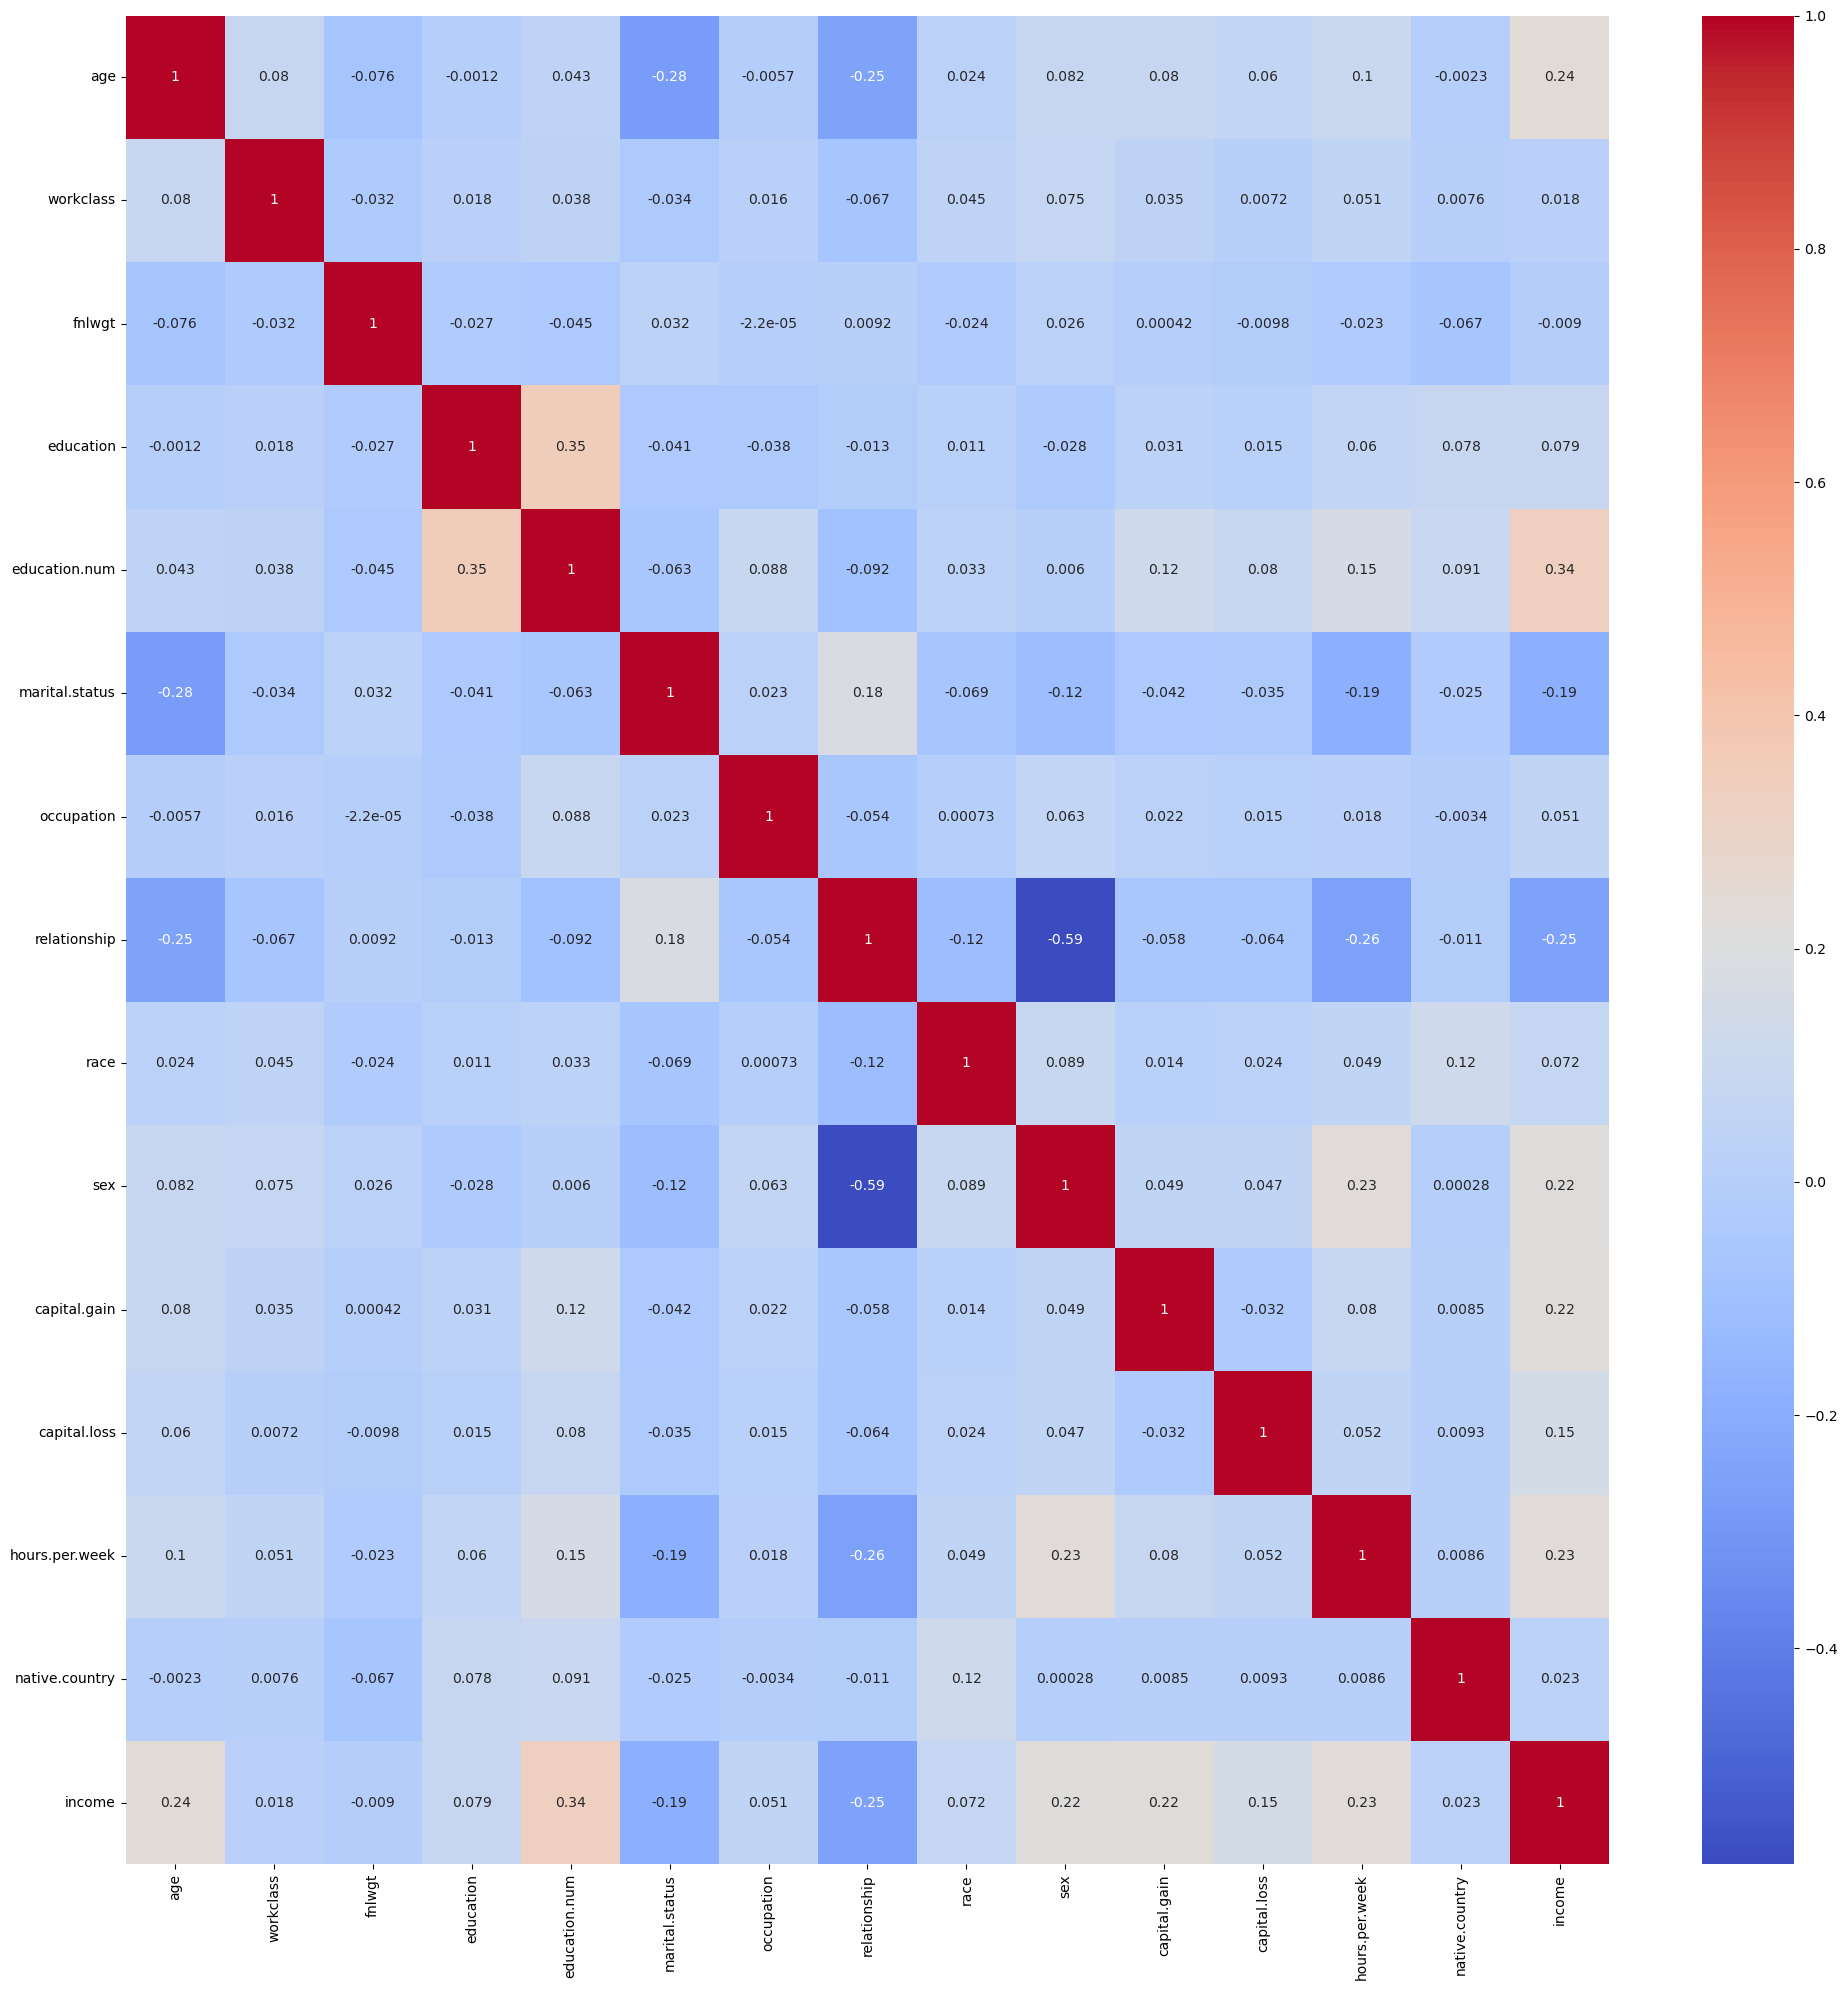

In [11]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

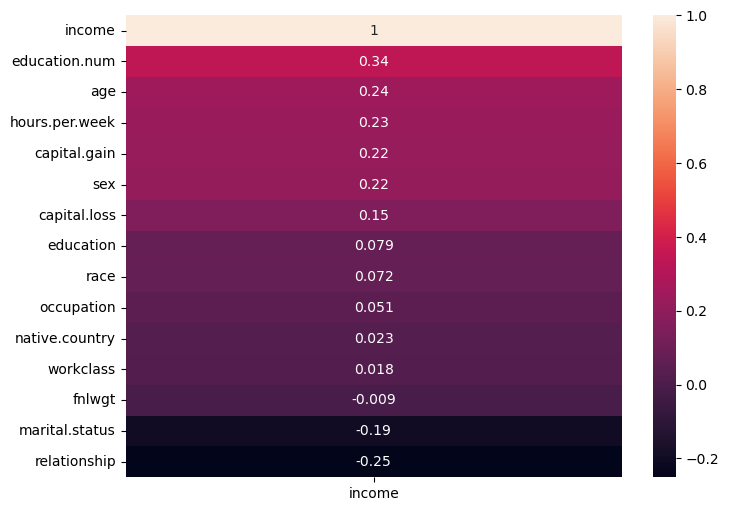

In [12]:
corr = df.corr()
labeled_corr = corr[['income']].sort_values('income', ascending=False)
fig = plt.figure(figsize=(8,6))
sns.heatmap(labeled_corr, annot=True)
plt.show()

## 6. Feature Scaling


In [13]:
# NOTE: Scaling moved AFTER train/test split (see Section 8)
# to avoid Data Leakage (fitting the scaler on test data statistics).


## 7. Outlier Handling (IQR Method)


In [14]:
def get_outlier_bounds(df, columns):
    bounds = {}
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        bounds[col] = (q1 - 1.5*iqr, q3 + 1.5*iqr)
    return bounds

def apply_capping(df, bounds):
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])
    return df

def remove_outliers(df, bounds):
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

# Apply Capping (not Removal) to columns where extreme values are likely
# noise/skew rather than real signal. capital.gain and capital.loss are
# intentionally EXCLUDED: their extreme values carry real predictive
# signal for income and should not be capped or removed.
cols_to_cap = ['age', 'fnlwgt', 'hours.per.week', 'education.num']
outlier_bounds = get_outlier_bounds(df, cols_to_cap)
df = apply_capping(df, outlier_bounds)

print("Outlier capping applied to:", cols_to_cap)
print("capital.gain and capital.loss left untouched (real predictive signal, not noise)")


Outlier capping applied to: ['age', 'fnlwgt', 'hours.per.week', 'education.num']
capital.gain and capital.loss left untouched (real predictive signal, not noise)


## Helper Functions for Visualization

In [15]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5,4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["<=50K", ">50K"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix - {title}")
    plt.tight_layout()
    plt.show()

def plot_roc_curve_single(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, color="darkorange", label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Random guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {title}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    return auc

def get_roc_data(y_true, y_prob, label):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    return fpr, tpr, auc, label


## 8. Train/Test Split


In [16]:
x = df.drop("income", axis=1)
y = df["income"]
print(y.value_counts())
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
sc = MinMaxScaler()
num_cols = x_train.select_dtypes(include=['int64', 'float64']).columns
x_train[num_cols] = sc.fit_transform(x_train[num_cols])
x_test[num_cols] = sc.transform(x_test[num_cols])

income
0    22633
1     7506
Name: count, dtype: int64


## 9. Model Training & Evaluation


### 1. Decision Tree


In [17]:
params = {
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid=params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV F1: 0.6794816301328694


In [18]:
# Use the tuned best estimator from GridSearchCV
dt = grid.best_estimator_
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
y_prob = dt.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

dt_acc = accuracy_score(y_test, y_pred)
dt_prec = precision_score(y_test, y_pred, average='weighted')
dt_rec = recall_score(y_test, y_pred, average='weighted')
dt_f1 = f1_score(y_test, y_pred, average='weighted')
dt_auc = roc_auc_score(y_test, y_prob)
dt_fpr, dt_tpr = roc_curve(y_test, y_prob)[:2]
print("Decision Tree Accuracy:", dt_acc, "| AUC:", dt_auc)


              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4580
           1       0.54      0.85      0.66      1448

    accuracy                           0.79      6028
   macro avg       0.74      0.81      0.75      6028
weighted avg       0.85      0.79      0.80      6028

[[3517 1063]
 [ 211 1237]]
Decision Tree Accuracy: 0.7886529528865295 | AUC: 0.8905954456078555


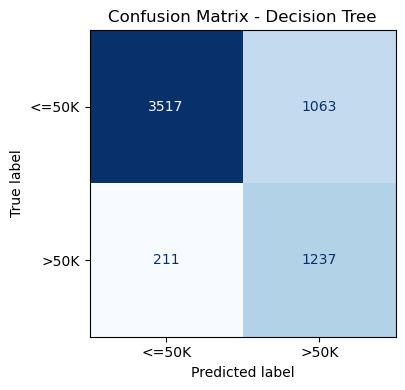

In [19]:
plot_confusion_matrix(y_test, y_pred, "Decision Tree")

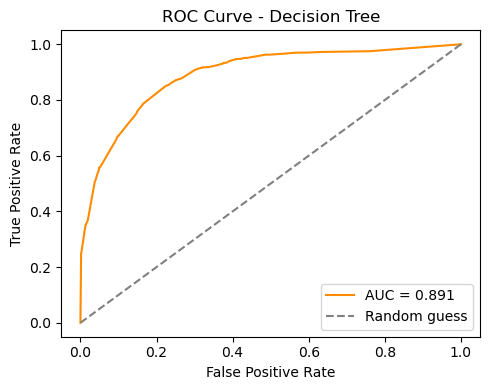

AUC Score - Decision Tree: 0.8906


In [20]:
plot_roc_curve_single(y_test, y_prob, "Decision Tree")
print(f"AUC Score - Decision Tree: {dt_auc:.4f}")

### 2. K-Nearest Neighbors (KNN)

Searching for the best `K` value, and using `weights='distance'` so closer neighbors have more influence.

Best K = 9
Accuracy = 0.8263


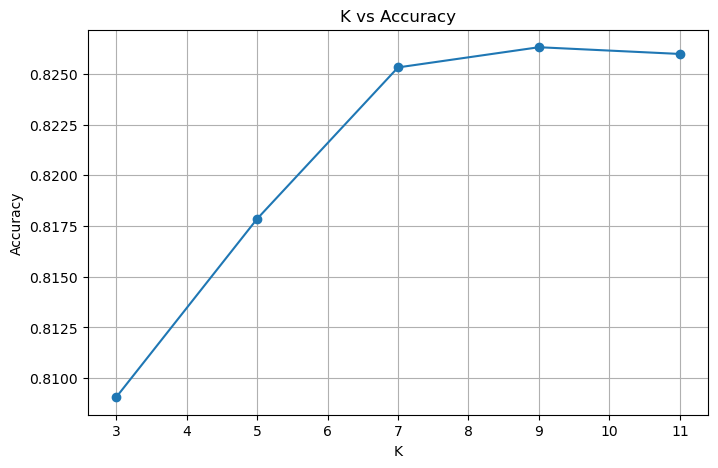

In [21]:
def find_best_k(X_train, X_test, y_train, y_test, k_range=(3,5,7,9,11)):
    acc = []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)
        acc.append(accuracy_score(y_test, pred))

    best_k = k_range[acc.index(max(acc))]
    print(f"Best K = {best_k}")
    print(f"Accuracy = {max(acc):.4f}")

    plt.figure(figsize=(8,5))
    plt.plot(list(k_range), acc, marker='o')
    plt.xlabel("K")
    plt.ylabel("Accuracy")
    plt.title("K vs Accuracy")
    plt.grid(True)
    plt.show()

    return best_k

best_k = find_best_k(x_train, x_test, y_train, y_test)

In [22]:
knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
y_prob = knn.predict_proba(x_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

knn_acc = accuracy_score(y_test, y_pred)
knn_prec = precision_score(y_test, y_pred, average='weighted')
knn_rec = recall_score(y_test, y_pred, average='weighted')
knn_f1 = f1_score(y_test, y_pred, average='weighted')
knn_auc = roc_auc_score(y_test, y_prob)
knn_fpr, knn_tpr = roc_curve(y_test, y_prob)[:2]
print("AUC:", knn_auc)


Accuracy: 0.8263105507631056

Confusion Matrix:
[[4143  437]
 [ 610  838]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      4580
           1       0.66      0.58      0.62      1448

    accuracy                           0.83      6028
   macro avg       0.76      0.74      0.75      6028
weighted avg       0.82      0.83      0.82      6028

AUC: 0.8551306273975247


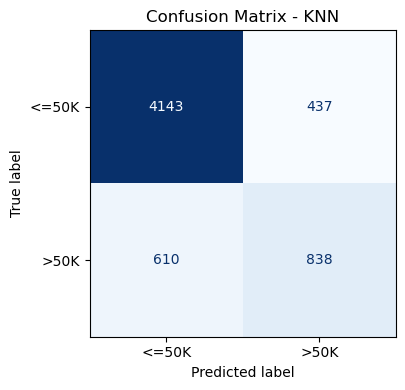

In [23]:
plot_confusion_matrix(y_test, y_pred, "KNN")

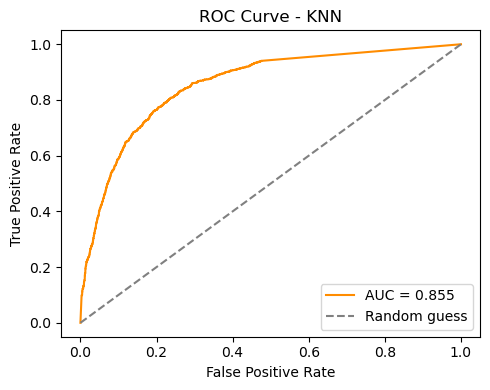

AUC Score - KNN: 0.8551


In [24]:
plot_roc_curve_single(y_test, y_prob, "KNN")
print(f"AUC Score - KNN: {knn_auc:.4f}")

### 3. Logistic Regression 


In [25]:
lr_params = {"C": [0.1, 1, 10]}
lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    param_grid=lr_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)
lr_grid.fit(x_train, y_train)
print("Best C:", lr_grid.best_params_)

lr = lr_grid.best_estimator_
y_pred = lr.predict(x_test)
y_prob = lr.predict_proba(x_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

lr_acc = accuracy_score(y_test, y_pred)
lr_prec = precision_score(y_test, y_pred, average='weighted')
lr_rec = recall_score(y_test, y_pred, average='weighted')
lr_f1 = f1_score(y_test, y_pred, average='weighted')
lr_auc = roc_auc_score(y_test, y_prob)
lr_fpr, lr_tpr = roc_curve(y_test, y_prob)[:2]
print("AUC:", lr_auc)


Best C: {'C': 10}
[[3543 1037]
 [ 363 1085]]
              precision    recall  f1-score   support

           0       0.91      0.77      0.84      4580
           1       0.51      0.75      0.61      1448

    accuracy                           0.77      6028
   macro avg       0.71      0.76      0.72      6028
weighted avg       0.81      0.77      0.78      6028

AUC: 0.8482149750295545


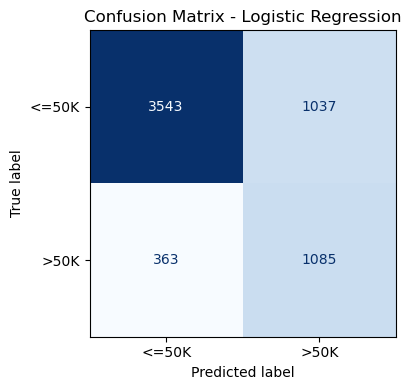

In [26]:
plot_confusion_matrix(y_test, y_pred, "Logistic Regression")

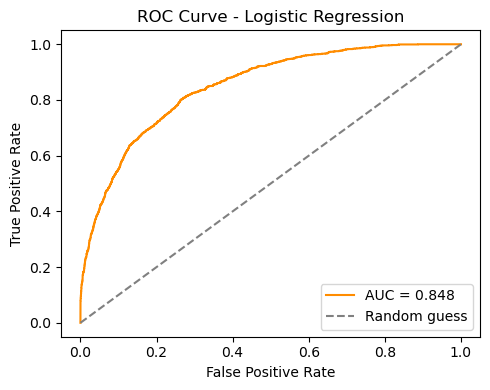

AUC Score - Logistic Regression: 0.8482


In [27]:
plot_roc_curve_single(y_test, y_prob, "Logistic Regression")
print(f"AUC Score - Logistic Regression: {lr_auc:.4f}")

### 4. Random Forest

In [28]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
y_prob = rf.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

rf_acc = accuracy_score(y_test, y_pred)
rf_prec = precision_score(y_test, y_pred, average='weighted')
rf_rec = recall_score(y_test, y_pred, average='weighted')
rf_f1 = f1_score(y_test, y_pred, average='weighted')
rf_auc = roc_auc_score(y_test, y_prob)
rf_fpr, rf_tpr = roc_curve(y_test, y_prob)[:2]
print("Random Forest Accuracy:", rf_acc, "| AUC:", rf_auc)


              precision    recall  f1-score   support

           0       0.94      0.81      0.87      4580
           1       0.59      0.84      0.69      1448

    accuracy                           0.82      6028
   macro avg       0.76      0.83      0.78      6028
weighted avg       0.86      0.82      0.83      6028

[[3718  862]
 [ 232 1216]]
Random Forest Accuracy: 0.818513603185136 | AUC: 0.9130106425969263


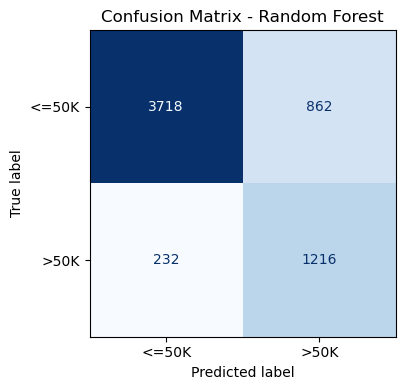

In [29]:
plot_confusion_matrix(y_test, y_pred, "Random Forest")

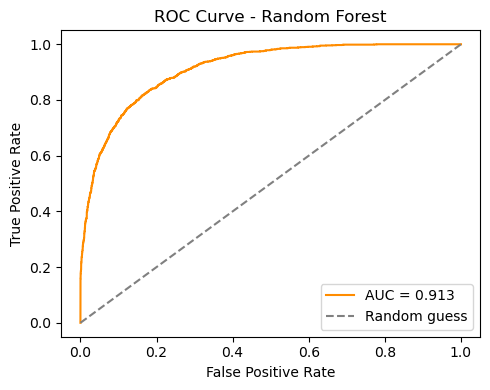

AUC Score - Random Forest: 0.9130


In [30]:
plot_roc_curve_single(y_test, y_prob, "Random Forest")
print(f"AUC Score - Random Forest: {rf_auc:.4f}")

## 10. ROC Curve Comparison


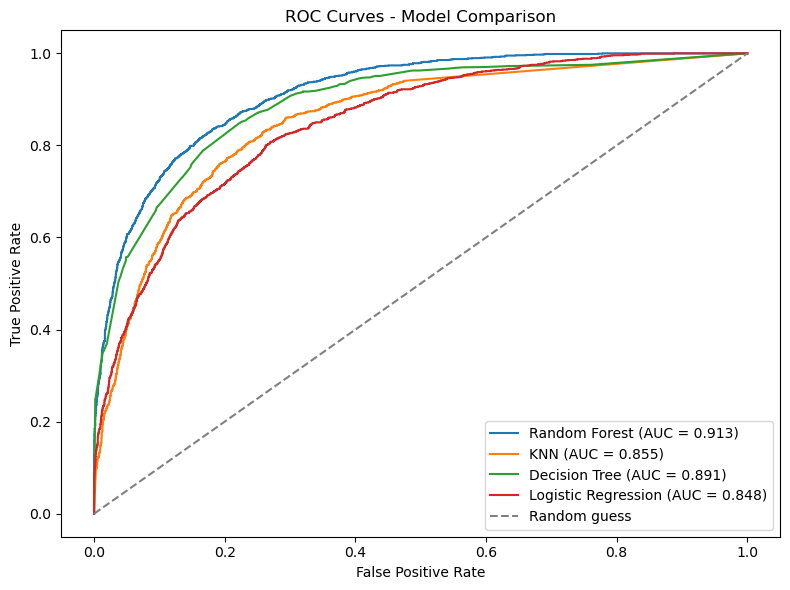

In [31]:
plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(knn_fpr, knn_tpr, label=f"KNN (AUC = {knn_auc:.3f})")
plt.plot(dt_fpr, dt_tpr, label=f"Decision Tree (AUC = {dt_auc:.3f})")
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Model Comparison Summary


In [32]:
results = pd.DataFrame({
    "Model": ["Random Forest", "KNN", "Decision Tree", "Logistic Regression"],
    "Accuracy": [rf_acc, knn_acc, dt_acc, lr_acc],
    "Precision": [rf_prec, knn_prec, dt_prec, lr_prec],
    "Recall": [rf_rec, knn_rec, dt_rec, lr_rec],
    "F1-score": [rf_f1, knn_f1, dt_f1, lr_f1],
    "AUC": [rf_auc, knn_auc, dt_auc, lr_auc],
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

results

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,KNN,0.826311,0.820157,0.826311,0.822403,0.855131
1,Random Forest,0.818514,0.855729,0.818514,0.828025,0.913011
2,Decision Tree,0.788653,0.845977,0.788653,0.801838,0.890595
3,Logistic Regression,0.767750,0.812001,0.767750,0.780451,0.848215
